<a href="https://colab.research.google.com/github/seirah-yang/BootCamp/blob/main/%ED%86%B5%EA%B3%84Tool_5_Repeated_ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 5. Repeated ANOVA

COVID19 전/후 연도별 약품 판매 트렌드 비교

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from pandas import Series, DataFrame
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/pharma-data.csv")
df.head()
#'['Distributor', 'Customer Name', 'City', 'Country', 'Latitude', 'Longitude', 'Channel', 'Sub-channel',
 #'Product Name', 'Product Class', 'Quantity', 'Price', 'Sales', 'Month', 'Year', 'Name of Sales Rep',
 #'Manager', 'Sales Team']

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
0,Gottlieb-Cruickshank,"Zieme, Doyle and Kunze",Lublin,Poland,51.2333,22.5667,Hospital,Private,Topipizole,Mood Stabilizers,4.0,368,1472.0,January,2018,Mary Gerrard,Britanny Bold,Delta
1,Gottlieb-Cruickshank,Feest PLC,Świecie,Poland,53.4167,18.4333,Pharmacy,Retail,Choriotrisin,Antibiotics,7.0,591,4137.0,January,2018,Jessica Smith,Britanny Bold,Delta
2,Gottlieb-Cruickshank,Medhurst-Beer Pharmaceutical Limited,Rybnik,Poland,50.0833,18.5000,Pharmacy,Institution,Acantaine,Antibiotics,30.0,66,1980.0,January,2018,Steve Pepple,Tracy Banks,Bravo
3,Gottlieb-Cruickshank,Barton Ltd Pharma Plc,Czeladź,Poland,50.3333,19.0833,Hospital,Private,Lioletine Refliruvax,Analgesics,6.0,435,2610.0,January,2018,Mary Gerrard,Britanny Bold,Delta
4,Gottlieb-Cruickshank,Keeling LLC Pharmacy,Olsztyn,Poland,53.7800,20.4942,Pharmacy,Retail,Oxymotroban Fexoformin,Analgesics,20.0,458,9160.0,January,2018,Anne Wu,Britanny Bold,Delta


In [ ]:
df.loc[df["Product Class"] == "Mood Stabilizers", "Product Name"], (df.loc[df["Product Class"] == "Analgesics", "Product Name"])

(0                   Topipizole
 5                    Pazofenac
 7         Morphizolid Tianalin
 8                      Lovapur
 10                Trazobalamin
                   ...         
 254052              Topipizole
 254060              Adriacaine
 254079                Adideine
 254080             Feruprazole
 254081             Feruprazole
 Name: Product Name, Length: 46415, dtype: object,
 3           Lioletine Refliruvax
 4         Oxymotroban Fexoformin
 6                      Symbitrim
 9                        Ampysin
 15            Neuropogen Empibax
                    ...          
 254035              Alglutriptan
 254036      Paronium Atracustone
 254042          Dantolac Pazocor
 254062              Topifribrate
 254076                Dasagestin
 Name: Product Name, Length: 44751, dtype: object)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/pharma-data.csv")
set(df["Year"].values.tolist()), set(df["Month"].values.tolist())

# year = {2017, 2018, 2019, 2020}
# month = {'April', 'August', 'December', 'February', 'January', 'July','June','March','May', 'November', 'October', 'September'})

({2017, 2018, 2019, 2020},
 {'April',
  'August',
  'December',
  'February',
  'January',
  'July',
  'June',
  'March',
  'May',
  'November',
  'October',
  'September'})

      Product Class  Year    Month   Sales     Period
0  Mood Stabilizers  2018  January  1472.0  Pre-COVID
1       Antibiotics  2018  January  4137.0  Pre-COVID
2       Antibiotics  2018  January  1980.0  Pre-COVID
3        Analgesics  2018  January  2610.0  Pre-COVID
4        Analgesics  2018  January  9160.0  Pre-COVID
Period
Pre-COVID     195671
Post-COVID     58411
Name: count, dtype: int64

===== Repeated ANOVA (Year Effect) =====
  Source            SS  DF            MS          F     p-unc       ng2  \
0   Year  1.221991e+09   3  4.073302e+08  27.781005  0.000002  0.632134   
1  Error  2.199327e+08  15  1.466218e+07        NaN       NaN       NaN   

        eps  
0  0.695604  
1       NaN  

===== Repeated  ANOVA (COVID Pre/Post Effect, based on: based on : 11/219)) =====
   Source            SS  DF            MS          F     p-unc       ng2  eps
0  Period  2.970333e+08   1  2.970333e+08  28.914224  0.002997  0.589542  1.0
1   Error  5.136457e+07   5  1.027291e+07        NaN

/tmp/ipython-input-2186636774.py:59: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x='Year', y='Sales', hue='Product Class', data=df, ci='sd', marker='o')


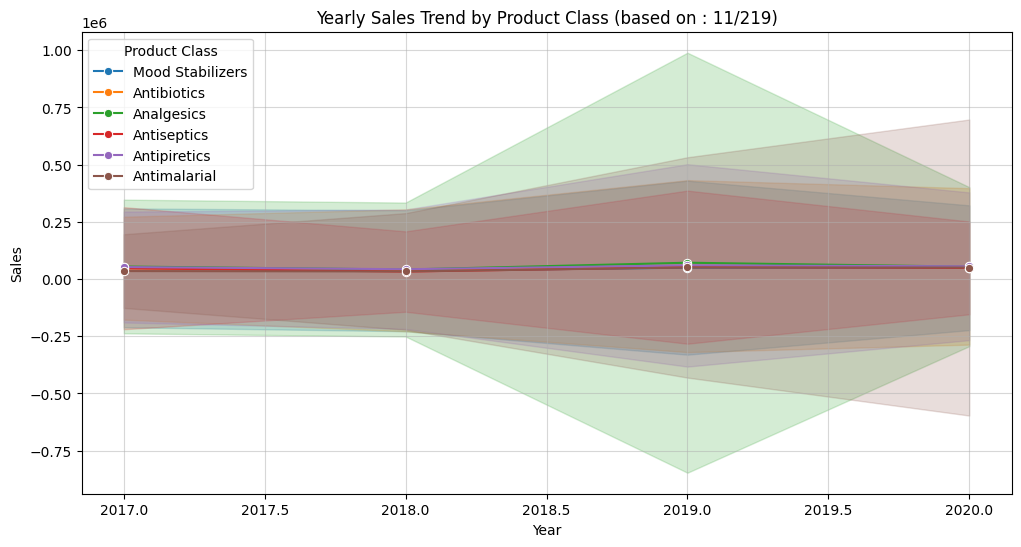

/tmp/ipython-input-2186636774.py:65: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='Period', y='Sales', hue='Product Class', data=avg_period, ci='sd', palette='Set2')


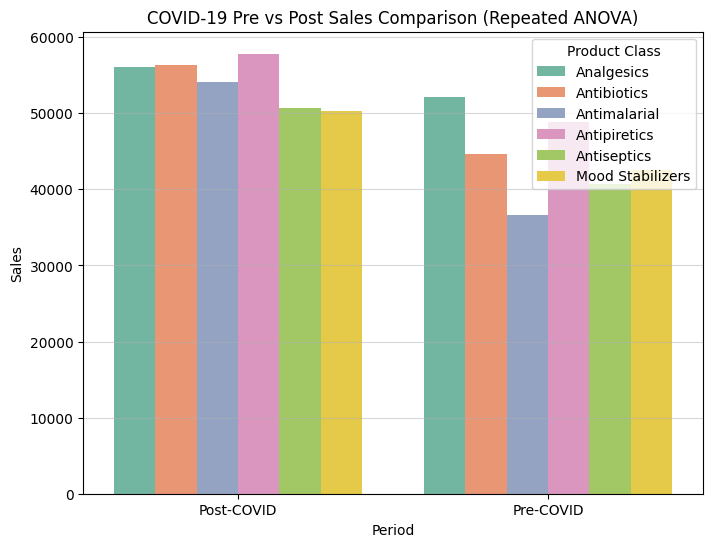

In [ ]:
# Repeated  ANOVA: COVID 전후(기준=2019년 11월)
import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns

# 1 데이터 로드
df = pd.read_csv("/content/drive/MyDrive/pharma-data.csv")

# Month  Datetime
month_map = {
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
}
if df['Month'].dtype == 'object':
    df['Month_num'] = df['Month'].map(month_map)
else:
    df['Month_num'] = df['Month']

# 2️. COVID 전후 구분 (기준: 2019년 11월)
def period_flag(year, month):
    if (year < 2019) or (year == 2019 and month < 11):
        return 'Pre-COVID'
    else:
        return 'Post-COVID'

df['Period'] = df.apply(lambda x: period_flag(x['Year'], x['Month_num']), axis=1)

print(df[['Product Class','Year','Month','Sales','Period']].head())
print(df['Period'].value_counts())

# 3. Repeated  ANOVA (연도별)
aov_year = pg.rm_anova(
    dv='Sales',
    within='Year',
    subject='Product Class',
    data=df,
    detailed=True
)
print("\n===== Repeated ANOVA (Year Effect) =====")
print(aov_year)

# 5. COVID 전후 비교 (Pre/Post)
avg_period = df.groupby(['Product Class','Period'])['Sales'].mean().reset_index()

aov_period = pg.rm_anova(
    dv='Sales',
    within='Period',
    subject='Product Class',
    data=avg_period,
    detailed=True
)
print("\n===== Repeated  ANOVA (COVID Pre/Post Effect, based on: based on : 11/219)) =====")
print(aov_period)

# 6️⃣ 시각화
plt.figure(figsize=(12,6))
sns.lineplot(x='Year', y='Sales', hue='Product Class', data=df, ci='sd', marker='o')
plt.title("Yearly Sales Trend by Product Class (based on : 11/219)")
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(8,6))
sns.barplot(x='Period', y='Sales', hue='Product Class', data=avg_period, ci='sd', palette='Set2')
plt.title("COVID-19 Pre vs Post Sales Comparison (Repeated ANOVA)")
plt.grid(axis='y', alpha=0.5)
plt.show()